# 01 — EDA Exploratorio: Dataset AI4MARS Completo

**Entregable 2 – Deep Learning**  
Estado del Arte, EDA Mejorado e Implementación de Modelos Benchmark

---

> **Objetivo de este notebook**  
> Realizar un análisis exploratorio sobre el **dataset completo AI4MARS** (las tres misiones: MSL, MER y M2020)  
> con las imágenes originales sin preprocesar. El análisis tiene dos propósitos:
> 1. Comprender la estructura global del dataset.
> 2. **Justificar empíricamente** la decisión de restringir el entrenamiento a imágenes de la misión MSL.
>
> Cada sección termina con una caja de implicaciones estructurada en:  
> `[D] Decisión de diseño | [A] Impacto en arquitectura | [R] Riesgo / data leakage`

---

**Índice**
1. Configuración e importaciones
2. Construcción del manifest
3. Limpieza de máscaras inválidas
4. Distribución global del dataset
5. Inspección visual comparativa por misión
6. Distribución de clases por misión (domain shift)
7. Dimensionalidad y formato por misión
8. Distribución de intensidades por misión
9. Divergencia Jensen-Shannon entre misiones
10. Decisión justificada: usar solo MSL
11. Definición del gold set de test (MSL min3)

## 1. Configuración e importaciones <a id="setup"></a>

In [ ]:
import os
import warnings
import hashlib
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from scipy.spatial.distance import jensenshannon

warnings.filterwarnings("ignore")

# ── Raíz del proyecto: un nivel arriba de notebooks/ ────────────────────────
NOTEBOOK_DIR = Path().resolve()
ROOT         = NOTEBOOK_DIR.parent

# ── Directorios de datos (rutas relativas a la raíz) ────────────────────────
MSL_IMG_TRAIN  = ROOT / "msl"   / "ncam" / "images" / "edr"
MSL_LBL_TRAIN  = ROOT / "msl"   / "ncam" / "labels" / "train"
MSL_LBL_TEST   = ROOT / "msl"   / "ncam" / "labels" / "test" / "masked-gold-min3-100agree"

MER_IMG_TRAIN  = ROOT / "mer"   / "images" / "eff"
MER_LBL_TRAIN  = ROOT / "mer"   / "labels" / "train" / "merged-unmasked"

M2020_IMG      = ROOT / "m2020" / "images" / "ncam"
M2020_LBL      = ROOT / "m2020" / "labels" / "NAV"

# ── Directorio de salida (dentro de notebooks/) ──────────────────────────────
PROCESSED_DIR = ROOT / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# ── Semilla para reproducibilidad ────────────────────────────────────────────
EDA_SEED = 42

print(f"Raíz del proyecto : {ROOT}")
print(f"Processed dir     : {PROCESSED_DIR}")
print("\nVerificando rutas de datos:")
for name, path in [
    ("MSL images train", MSL_IMG_TRAIN),
    ("MSL labels train", MSL_LBL_TRAIN),
    ("MSL labels test (gold)", MSL_LBL_TEST),
    ("MER images",      MER_IMG_TRAIN),
    ("MER labels",      MER_LBL_TRAIN),
    ("M2020 images",    M2020_IMG),
    ("M2020 labels",    M2020_LBL),
]:
    status = "✓" if path.exists() else "✗ NO ENCONTRADO"
    print(f"  [{status}] {name}: {path.relative_to(ROOT)}")

Raíz del proyecto : C:\Users\User\Documents\DeepLearning\ai4mars_DL-v3
Processed dir     : C:\Users\User\Documents\DeepLearning\ai4mars_DL-v3\notebooks\processed

Verificando rutas de datos:
  [✓] MSL images train: msl\ncam\images\edr
  [✓] MSL labels train: msl\ncam\labels\train
  [✓] MSL labels test (gold): msl\ncam\labels\test\masked-gold-min3-100agree
  [✓] MER images: mer\images\eff
  [✓] MER labels: mer\labels\train\merged-unmasked
  [✓] M2020 images: m2020\images\ncam
  [✓] M2020 labels: m2020\labels\NAV


In [3]:
# ── Paleta de colores por clase (colorblind-friendly) ───────────────────────
CLASS_COLORS = {
    0:   ("#E69F00", "soil"),
    1:   ("#56B4E9", "bedrock"),
    2:   ("#009E73", "sand"),
    3:   ("#D55E00", "big_rock"),
    255: ("#999999", "ignore"),
}
CLASS_NAMES  = {c: CLASS_COLORS[c][1] for c in [0, 1, 2, 3]}

# ── Paleta por misión ────────────────────────────────────────────────────────
MISSION_COLORS = {"MSL": "#0072B2", "MER": "#CC79A7", "M2020": "#F0E442"}

NUM_CLASSES  = 4
IGNORE_INDEX = 255

print("Constantes y paletas definidas.")
print(f"Clases   : {list(CLASS_NAMES.values())}")
print(f"Misiones : {list(MISSION_COLORS.keys())}")

Constantes y paletas definidas.
Clases   : ['soil', 'bedrock', 'sand', 'big_rock']
Misiones : ['MSL', 'MER', 'M2020']


## 2. Construcción del manifest <a id="manifest"></a>

Se construye un CSV con todas las parejas imagen-máscara del dataset completo.  
Las rutas se guardan **relativas a la raíz del proyecto** para garantizar portabilidad entre máquinas.

La función `canonical_name` elimina los sufijos `_merged` y `_0LLJ` que aparecen en algunos nombres
de archivo de las máscaras, permitiendo el match con los nombres de las imágenes.

In [4]:
def canonical_name(stem: str) -> str:
    """Normaliza el stem de un archivo eliminando sufijos variables."""
    stem = stem.replace("_0LLJ", "")
    for i in range(1, 100):
        stem = stem.replace(f"_merged{i}", "")
    stem = stem.replace("_merged", "")   # sin número
    return stem


def build_manifest(
    image_dir: Path,
    label_dir: Path,
    mission:   str,
    camera:    str,
    root:      Path,
) -> pd.DataFrame:
    """
    Construye un manifest emparejando imágenes y máscaras por canonical_name.
    Las rutas se almacenan relativas a `root`.
    """
    img_extensions = {".jpg", ".jpeg", ".png"}

    images = {}
    for img in image_dir.iterdir():
        if img.suffix.lower() in img_extensions:
            key = canonical_name(img.stem)
            images[key] = img

    labels = {}
    for lbl in label_dir.iterdir():
        if lbl.suffix.lower() == ".png":
            key = canonical_name(lbl.stem)
            labels[key] = lbl

    keys = set(images.keys()) & set(labels.keys())

    rows = []
    for k in sorted(keys):
        rows.append({
            "mission":    mission,
            "camera":     camera,
            "id":         k,
            "image_path": str(images[k].relative_to(root)),
            "mask_path":  str(labels[k].relative_to(root)),
            "split":      "train",   # se actualizará para el gold set
        })

    df = pd.DataFrame(rows)
    print(f"  {mission:5s} ({camera}): {len(df):>5,} pares imagen-máscara encontrados")
    return df


print("Construyendo manifest por misión...")
msl_train_df = build_manifest(MSL_IMG_TRAIN, MSL_LBL_TRAIN, "MSL",  "ncam", ROOT)
mer_df       = build_manifest(MER_IMG_TRAIN, MER_LBL_TRAIN, "MER",  "eff",  ROOT)
m2020_df     = build_manifest(M2020_IMG,     M2020_LBL,     "M2020","ncam", ROOT)

# Gold set MSL: split="test", no entra al pool de entrenamiento
msl_gold_df = build_manifest(MSL_IMG_TRAIN, MSL_LBL_TEST, "MSL", "ncam", ROOT)
msl_gold_df["split"] = "test_gold"
print(f"  MSL gold set (min3): {len(msl_gold_df):>5,} imágenes de test fijo")

# Manifest completo (incluye gold set con split marcado)
df_all = pd.concat([msl_train_df, mer_df, m2020_df, msl_gold_df], ignore_index=True)

print(f"\nTotal pares encontrados: {len(df_all):,}")
print("\nDistribución por misión:")
print(df_all.groupby(["mission", "split"]).size().to_string())

Construyendo manifest por misión...
  MSL   (ncam): 16,064 pares imagen-máscara encontrados
  MER   (eff): 7,391 pares imagen-máscara encontrados
  M2020 (ncam):   473 pares imagen-máscara encontrados
  MSL   (ncam):   322 pares imagen-máscara encontrados
  MSL gold set (min3):   322 imágenes de test fijo

Total pares encontrados: 24,250

Distribución por misión:
mission  split    
M2020    train          473
MER      train         7391
MSL      test_gold      322
         train        16064


## 3. Limpieza de máscaras inválidas <a id="limpieza"></a>

Se eliminan las máscaras que no aportan información útil al entrenamiento:
- Máscaras con un único valor (vacías).
- Máscaras compuestas únicamente por píxeles `ignore` (255).

> **Nota**: el gold set de test NO se filtra — se mantiene intacto para preservar la comparabilidad con la literatura.

In [5]:
def is_valid_mask(mask_rel_path: str, root: Path) -> tuple[bool, str]:
    """
    Devuelve (es_válida, razón_de_rechazo).
    Una máscara es inválida si tiene un único valor o si ese valor es 255.
    """
    mask = np.array(Image.open(root / mask_rel_path))
    unique = set(np.unique(mask).tolist())
    if len(unique) == 1:
        return False, "single_value"
    if unique == {255}:
        return False, "only_ignore"
    return True, ""


# Filtrar solo el pool de train (no el gold set)
train_pool = df_all[df_all["split"] == "train"].copy()
gold_set   = df_all[df_all["split"] == "test_gold"].copy()

print(f"Verificando {len(train_pool):,} máscaras del pool de entrenamiento...")
valid_flags, reasons = [], []
for _, row in tqdm(train_pool.iterrows(), total=len(train_pool), desc="Limpieza"):
    ok, reason = is_valid_mask(row["mask_path"], ROOT)
    valid_flags.append(ok)
    reasons.append(reason)

train_pool["valid"]  = valid_flags
train_pool["reason"] = reasons

# Reporte de eliminaciones
removed = train_pool[~train_pool["valid"]]
print(f"\nMáscaras eliminadas: {len(removed):,}")
print(removed["reason"].value_counts().to_string())
print(f"\nPor misión:")
print(removed.groupby(["mission", "reason"]).size().to_string())

# Dataset limpio
train_clean = train_pool[train_pool["valid"]].drop(columns=["valid", "reason"]).reset_index(drop=True)
print(f"\nPool de entrenamiento limpio: {len(train_clean):,} muestras")
print(train_clean["mission"].value_counts().to_string())

Verificando 23,928 máscaras del pool de entrenamiento...


Limpieza: 100%|██████████| 23928/23928 [03:04<00:00, 129.66it/s]



Máscaras eliminadas: 963
reason
single_value    963

Por misión:
mission  reason      
M2020    single_value      2
MER      single_value    798
MSL      single_value    163

Pool de entrenamiento limpio: 22,965 muestras
mission
MSL      15901
MER       6593
M2020      471


In [6]:
# Guardar manifest completo limpio (train pool + gold set)
df_clean = pd.concat([train_clean, gold_set], ignore_index=True)
df_clean.to_csv(PROCESSED_DIR / "manifest_clean.csv", index=False)

print(f"manifest_clean.csv guardado: {len(df_clean):,} muestras totales")
print("\nDesglose final:")
print(df_clean.groupby(["mission", "split"]).size().to_string())

manifest_clean.csv guardado: 23,287 muestras totales

Desglose final:
mission  split    
M2020    train          471
MER      train         6593
MSL      test_gold      322
         train        15901


**Implicaciones – Limpieza de máscaras**

| | |
|---|---|
| **[D] Decisión** | Eliminar máscaras vacías o de solo-ignore del pool de entrenamiento. El gold set se mantiene íntegro. |
| **[A] Arquitectura** | No aplica directamente. |
| **[R] Riesgo** | Si la proporción de eliminaciones es desigual entre misiones, puede sesgar la representación relativa. Se verifica en la sección siguiente. |

## 4. Distribución global del dataset <a id="distribucion"></a>

Análisis de la composición del dataset por misión, cámara y tamaño relativo.

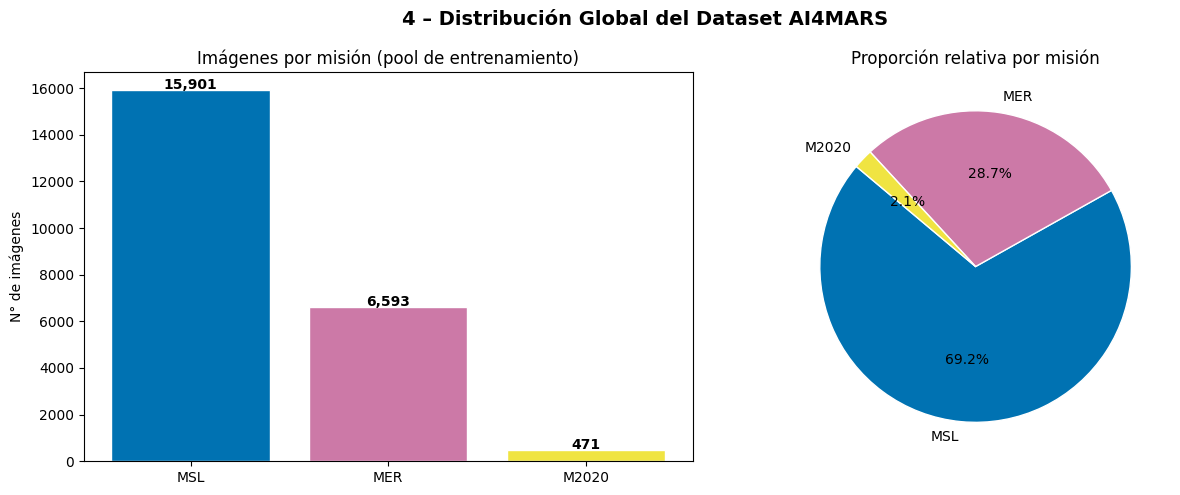

Distribución por misión:
  MSL  : 15,901 imágenes  (69.2%)
  MER  :  6,593 imágenes  (28.7%)
  M2020:    471 imágenes  (2.1%)

  Gold set MSL (test fijo):    322 imágenes


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("4 – Distribución Global del Dataset AI4MARS", fontsize=14, fontweight="bold")

# Conteo por misión (solo train pool)
mission_counts = train_clean["mission"].value_counts()
colors_m = [MISSION_COLORS[m] for m in mission_counts.index]

bars = axes[0].bar(mission_counts.index, mission_counts.values, color=colors_m, edgecolor="white")
for bar, val in zip(bars, mission_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{val:,}",
        ha="center", fontsize=10, fontweight="bold"
    )
axes[0].set_ylabel("N° de imágenes")
axes[0].set_title("Imágenes por misión (pool de entrenamiento)")

# Pie: distribución relativa
axes[1].pie(
    mission_counts.values,
    labels=mission_counts.index,
    colors=colors_m,
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops=dict(edgecolor="white")
)
axes[1].set_title("Proporción relativa por misión")

plt.tight_layout()
plt.show()

print("Distribución por misión:")
for mission, count in mission_counts.items():
    pct = count / len(train_clean) * 100
    print(f"  {mission:5s}: {count:>6,} imágenes  ({pct:.1f}%)")
print(f"\n  Gold set MSL (test fijo): {len(gold_set):>6,} imágenes")

**Implicaciones – Distribución global**

| | |
|---|---|
| **[D] Decisión** | MSL domina el dataset (~70%). M2020 es fuertemente minoritaria. Cualquier split aleatorio sin estratificación dejaría M2020 sub o sobrerepresentada. |
| **[A] Arquitectura** | La dominancia de MSL justifica su uso como conjunto principal de entrenamiento. |
| **[R] Riesgo** | Si se mezclan misiones sin control, el modelo puede aprender características específicas de sensor (cámara NavCam MSL vs EFF MER) en lugar de características de terreno. |

## 5. Inspección visual comparativa por misión <a id="visual"></a>

Se visualizan muestras aleatorias de cada misión para identificar diferencias
visuales sistemáticas: iluminación, resolución, ángulo de cámara y ruido.

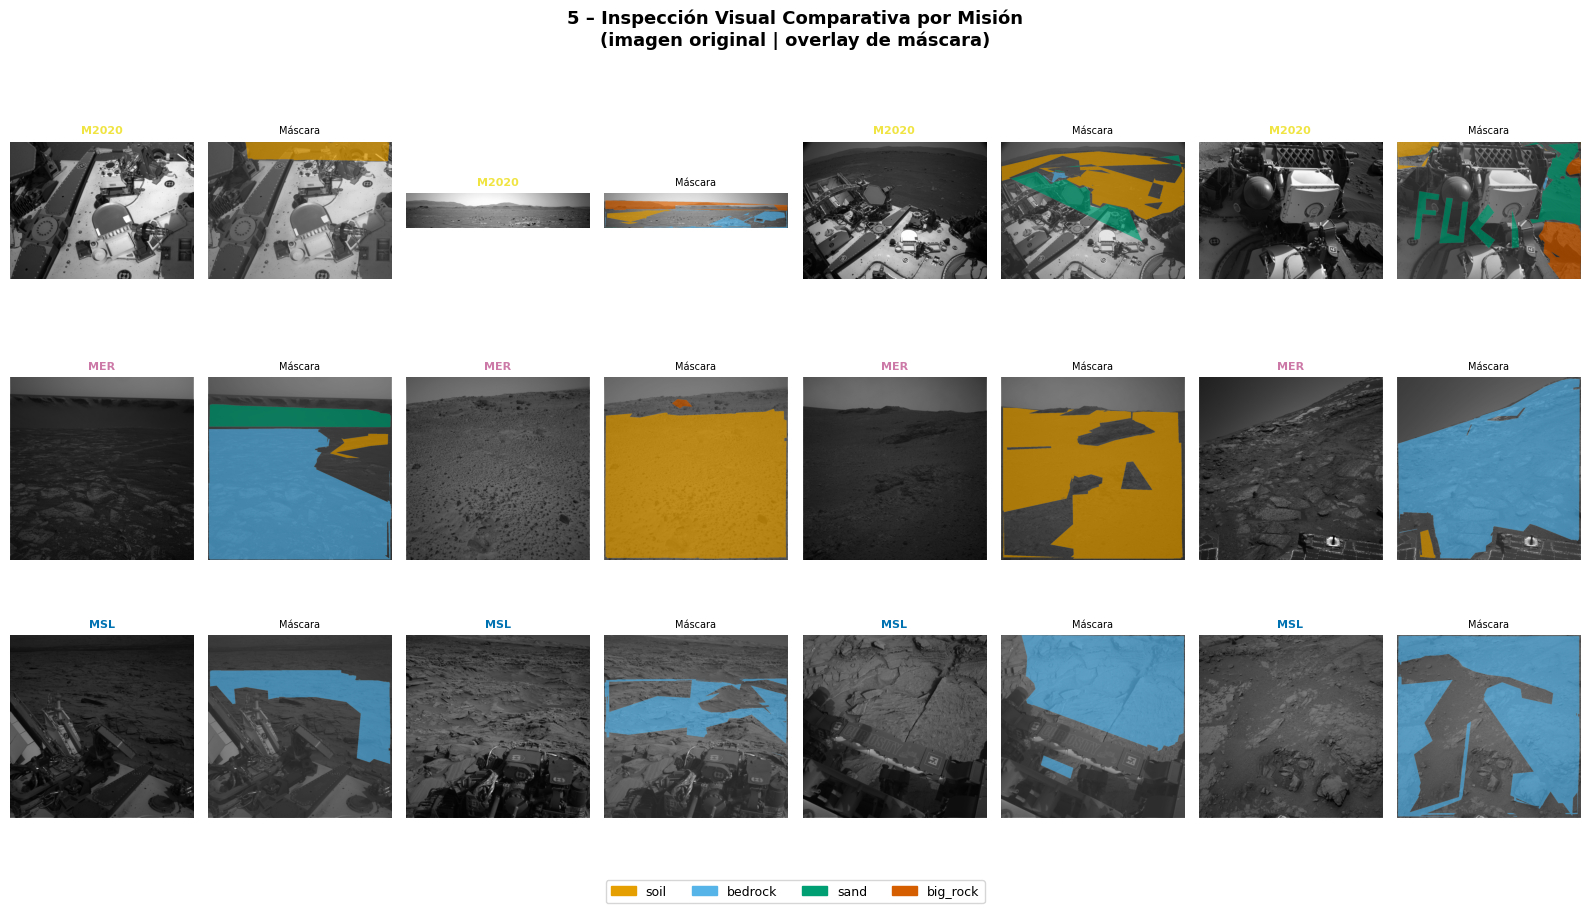

In [8]:
def show_mission_samples(
    df: pd.DataFrame,
    root: Path,
    n_per_mission: int = 4,
    seed: int = EDA_SEED
) -> None:
    """Visualiza n muestras por misión con su máscara superpuesta."""
    missions = sorted(df["mission"].unique())
    fig, axes = plt.subplots(
        len(missions), n_per_mission * 2,
        figsize=(n_per_mission * 4, len(missions) * 3)
    )
    fig.suptitle(
        "5 – Inspección Visual Comparativa por Misión\n(imagen original | overlay de máscara)",
        fontsize=13, fontweight="bold"
    )

    rng = np.random.default_rng(seed)

    for row_idx, mission in enumerate(missions):
        subset = df[df["mission"] == mission]
        chosen = subset.sample(min(n_per_mission, len(subset)), random_state=seed)

        for col_idx, (_, sample) in enumerate(chosen.iterrows()):
            img  = np.array(Image.open(root / sample["image_path"]).convert("L"))
            mask = np.array(Image.open(root / sample["mask_path"]))

            ax_img  = axes[row_idx][col_idx * 2]
            ax_mask = axes[row_idx][col_idx * 2 + 1]

            ax_img.imshow(img, cmap="gray")
            ax_img.set_title(f"{mission}", fontsize=8, fontweight="bold",
                             color=MISSION_COLORS[mission])
            ax_img.axis("off")

            # Overlay con colores por clase
            overlay = np.zeros((*mask.shape, 4), dtype=np.uint8)
            for cls_id, (hex_color, _) in CLASS_COLORS.items():
                if cls_id == 255:
                    continue
                rgb = tuple(int(hex_color[i:i+2], 16) for i in (1, 3, 5))
                overlay[mask == cls_id] = [*rgb, 180]
            overlay[mask == 255] = [150, 150, 150, 60]

            ax_mask.imshow(img, cmap="gray")
            ax_mask.imshow(overlay)
            ax_mask.set_title(f"Máscara", fontsize=7)
            ax_mask.axis("off")

    # Leyenda global
    patches = [
        mpatches.Patch(color=CLASS_COLORS[c][0], label=CLASS_COLORS[c][1])
        for c in [0, 1, 2, 3]
    ]
    fig.legend(handles=patches, loc="lower center", ncol=4,
               fontsize=9, bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    plt.show()


show_mission_samples(train_clean, ROOT, n_per_mission=4)

**Implicaciones – Inspección visual**

| | |
|---|---|
| **[D] Decisión** | Las diferencias visuales entre misiones (contraste, granularidad, ángulo) son observables a simple vista. Un modelo entrenado en MSL probablemente no generalizará directamente a MER sin domain adaptation. |
| **[A] Arquitectura** | Justifica mantener las misiones separadas y no mezclarlas de forma ingenua en el set de entrenamiento. |
| **[R] Riesgo** | El etiquetado por crowdsourcing puede ser menos consistente en MER y M2020. Las máscaras con ruido estructural en los bordes son inherentes al dataset. |

## 6. Distribución de clases por misión (domain shift) <a id="clases"></a>

Se mide la distribución de píxeles por clase en cada misión usando muestreo estratificado.
Diferencias sistemáticas en esta distribución son evidencia directa de **domain shift**.

Calculando distribución de clases por misión...


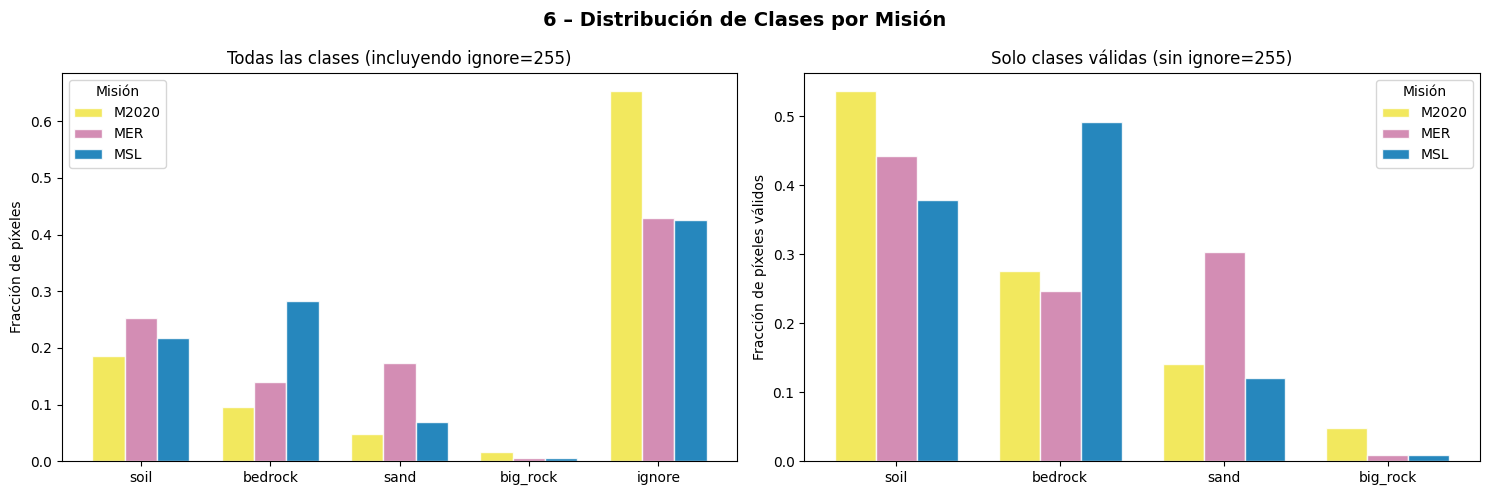


Distribución detallada por misión (clases válidas):
  M2020:
    soil      : 0.536
    bedrock   : 0.275
    sand      : 0.140
    big_rock  : 0.049
  MER:
    soil      : 0.442
    bedrock   : 0.246
    sand      : 0.303
    big_rock  : 0.009
  MSL:
    soil      : 0.379
    bedrock   : 0.492
    sand      : 0.121
    big_rock  : 0.008


In [9]:
def pixel_counts_by_mission(
    df: pd.DataFrame,
    root: Path,
    sample_per_mission: int = 200,
    seed: int = EDA_SEED
) -> dict:
    """Distribución de píxeles por clase para cada misión (fracción del total)."""
    results = {}
    for mission, group in df.groupby("mission"):
        n = min(sample_per_mission, len(group))
        sample = group.sample(n, random_state=seed)
        counts = defaultdict(int)
        for _, row in tqdm(sample.iterrows(), total=n,
                           desc=f"  Contando píxeles {mission}", leave=False):
            mask = np.array(Image.open(root / row["mask_path"]))
            vals, cnts = np.unique(mask, return_counts=True)
            for v, c in zip(vals, cnts):
                counts[int(v)] += int(c)
        total = sum(counts.values())
        results[mission] = {k: v / total for k, v in counts.items()}
    return results


print("Calculando distribución de clases por misión...")
dist_mission = pixel_counts_by_mission(train_clean, ROOT, sample_per_mission=200)

missions  = sorted(dist_mission.keys())
cls_order = [0, 1, 2, 3, 255]
x     = np.arange(len(cls_order))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("6 – Distribución de Clases por Misión", fontsize=14, fontweight="bold")

# Barras agrupadas
for i, mission in enumerate(missions):
    dist = dist_mission[mission]
    vals = [dist.get(c, 0) for c in cls_order]
    axes[0].bar(x + i * width, vals, width,
                label=mission, color=MISSION_COLORS[mission],
                edgecolor="white", alpha=0.85)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels([CLASS_COLORS[c][1] for c in cls_order])
axes[0].set_ylabel("Fracción de píxeles")
axes[0].legend(title="Misión")
axes[0].set_title("Todas las clases (incluyendo ignore=255)")

# Solo clases válidas, normalizado
for i, mission in enumerate(missions):
    dist = dist_mission[mission]
    valid_total = sum(dist.get(c, 0) for c in [0, 1, 2, 3])
    if valid_total == 0:
        continue
    vals = [dist.get(c, 0) / valid_total for c in [0, 1, 2, 3]]
    axes[1].bar(np.arange(4) + i * width, vals, width,
                label=mission, color=MISSION_COLORS[mission],
                edgecolor="white", alpha=0.85)

axes[1].set_xticks(np.arange(4) + width)
axes[1].set_xticklabels([CLASS_COLORS[c][1] for c in [0, 1, 2, 3]])
axes[1].set_ylabel("Fracción de píxeles válidos")
axes[1].legend(title="Misión")
axes[1].set_title("Solo clases válidas (sin ignore=255)")

plt.tight_layout()
plt.show()

print("\nDistribución detallada por misión (clases válidas):")
for mission, dist in dist_mission.items():
    valid_total = sum(dist.get(c, 0) for c in [0, 1, 2, 3])
    if valid_total == 0:
        continue
    print(f"  {mission}:")
    for c in [0, 1, 2, 3]:
        print(f"    {CLASS_COLORS[c][1]:10s}: {dist.get(c, 0)/valid_total:.3f}")

**Implicaciones – Distribución de clases por misión**

| | |
|---|---|
| **[D] Decisión** | Diferencias en la distribución de clases entre misiones confirman domain shift. No es apropiado mezclar misiones sin técnicas de domain adaptation. |
| **[A] Arquitectura** | La distribución de clases dentro de MSL (la misión elegida) determina los pesos de la función de pérdida. |
| **[R] Riesgo** | Un modelo entrenado en MSL verá distribuciones de clase distintas en MER/M2020. Documentar como limitación de generalización. |

## 7. Dimensionalidad y formato por misión <a id="dimensiones"></a>

Se analiza la distribución de resoluciones de imagen en cada misión.
Diferencias en el aspect ratio y resolución entre misiones son indicadores adicionales de domain shift.

Analizando dimensiones de imagen por misión...


Midiendo imágenes: 100%|██████████| 300/300 [00:00<00:00, 1362.42it/s]


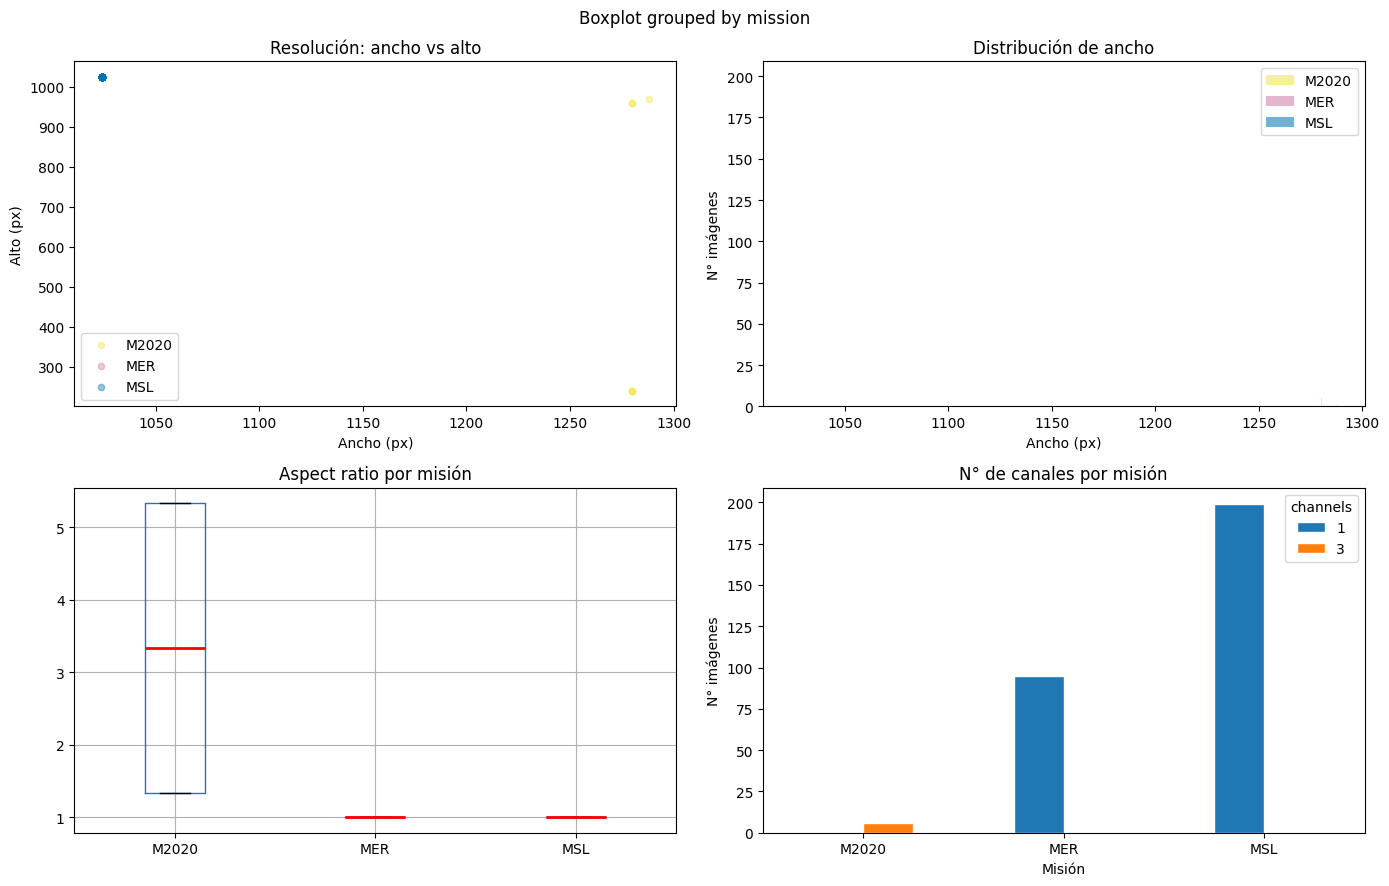


Resumen de dimensiones por misión:
          width              height             aspect           channels        
         median   min   max  median   min   max median  min  max   median min max
mission                                                                          
M2020    1280.0  1280  1288   600.0   240   968    3.3  1.3  5.3      3.0   3   3
MER      1024.0  1024  1024  1024.0  1024  1024    1.0  1.0  1.0      1.0   1   1
MSL      1024.0  1024  1024  1024.0  1024  1024    1.0  1.0  1.0      1.0   1   1


In [10]:
def get_image_sizes(
    df: pd.DataFrame,
    root: Path,
    sample_n: int = 300,
    seed: int = EDA_SEED
) -> pd.DataFrame:
    """Mide ancho, alto y canales de una muestra de imágenes."""
    sample = df.sample(min(sample_n, len(df)), random_state=seed)
    records = []
    for _, row in tqdm(sample.iterrows(), total=len(sample), desc="Midiendo imágenes"):
        img = Image.open(root / row["image_path"])
        w, h = img.size
        records.append({
            "mission": row["mission"],
            "width":   w,
            "height":  h,
            "channels": len(img.getbands()),
            "aspect":  w / h,
        })
    return pd.DataFrame(records)


print("Analizando dimensiones de imagen por misión...")
sizes_df = get_image_sizes(train_clean, ROOT, sample_n=300)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("7 – Dimensionalidad y Formato por Misión", fontsize=14, fontweight="bold")

# Scatter width vs height por misión
for mission in missions:
    sub = sizes_df[sizes_df["mission"] == mission]
    axes[0][0].scatter(sub["width"], sub["height"],
                       label=mission, alpha=0.4, s=20,
                       color=MISSION_COLORS[mission])
axes[0][0].set_xlabel("Ancho (px)"); axes[0][0].set_ylabel("Alto (px)")
axes[0][0].set_title("Resolución: ancho vs alto"); axes[0][0].legend()

# Histograma de ancho por misión
for mission in missions:
    sub = sizes_df[sizes_df["mission"] == mission]
    axes[0][1].hist(sub["width"], bins=20, alpha=0.55,
                    color=MISSION_COLORS[mission], label=mission)
axes[0][1].set_xlabel("Ancho (px)"); axes[0][1].set_ylabel("N° imágenes")
axes[0][1].set_title("Distribución de ancho"); axes[0][1].legend()

# Boxplot de aspect ratio por misión
sizes_df.boxplot(column="aspect", by="mission", ax=axes[1][0],
                 medianprops=dict(color="red", linewidth=2))
axes[1][0].set_title("Aspect ratio (ancho/alto)"); axes[1][0].set_xlabel("")
plt.sca(axes[1][0]); plt.title("Aspect ratio por misión")

# Canales
ch_counts = sizes_df.groupby(["mission", "channels"]).size().unstack(fill_value=0)
ch_counts.plot(kind="bar", ax=axes[1][1], edgecolor="white")
axes[1][1].set_title("N° de canales por misión")
axes[1][1].set_xlabel("Misión"); axes[1][1].set_ylabel("N° imágenes")
axes[1][1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

print("\nResumen de dimensiones por misión:")
print(sizes_df.groupby("mission")[["width", "height", "aspect", "channels"]].agg(
    ["median", "min", "max"]
).round(1).to_string())

**Implicaciones – Dimensionalidad y formato**

| | |
|---|---|
| **[D] Decisión** | Las resoluciones varían entre misiones. Se aplicará resize a **256×256** con interpolación BILINEAR para imágenes y NEAREST para máscaras. |
| **[A] Arquitectura** | Todos los modelos recibirán input fijo `[B, 3, 256, 256]`. El canal grayscale se replica ×3 para compatibilidad con encoders preentrenados en ImageNet. |
| **[R] Riesgo** | Imágenes con aspect ratio muy distinto de 1:1 pierden información geométrica al hacer resize cuadrado. Documentar como limitación estructural del preprocesamiento. |

## 8. Distribución de intensidades por misión <a id="intensidades"></a>

Diferencias en la distribución de intensidades de píxeles entre misiones
indican condiciones de iluminación distintas y características de sensor diferentes.

Analizando distribución de intensidades por misión...


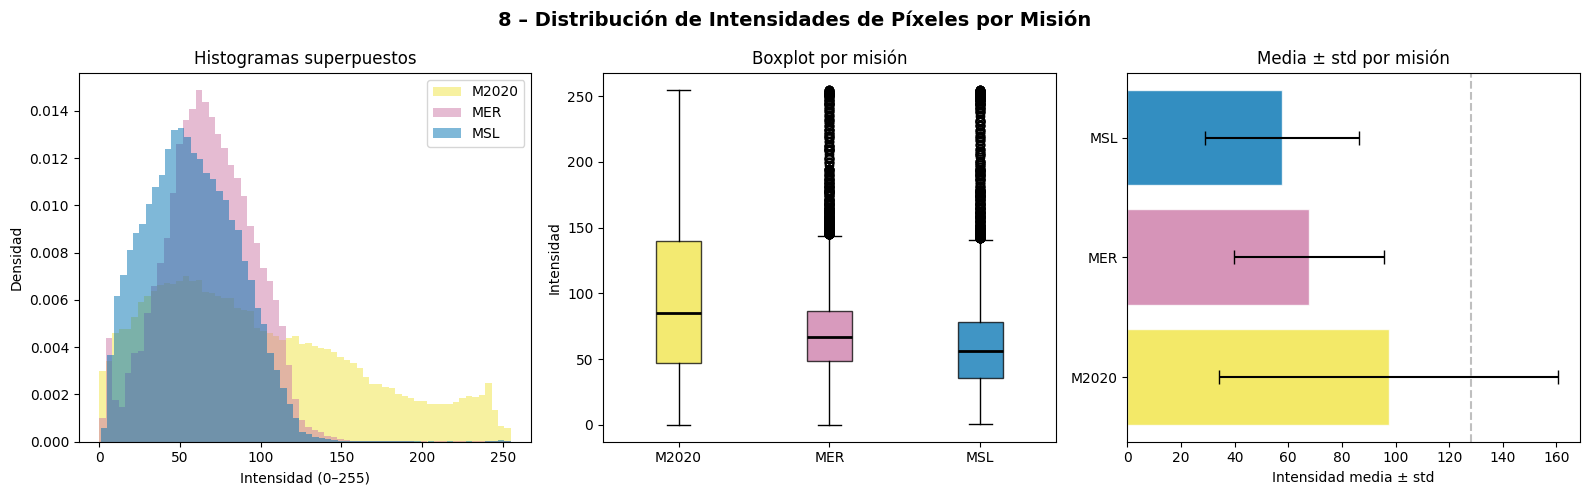


Estadísticas de intensidad por misión:
  M2020: media=97.5  std=63.3  p5=13  p95=224
  MER  : media=67.6  std=27.9  p5=20  p95=112
  MSL  : media=57.7  std=28.7  p5=14  p95=105


In [11]:
def pixel_intensity_by_mission(
    df: pd.DataFrame,
    root: Path,
    sample_per_mission: int = 150,
    px_per_img: int = 1000,
    seed: int = EDA_SEED
) -> dict:
    """Extrae muestras de intensidad de píxeles por misión."""
    rng = np.random.default_rng(seed)
    result = {}
    for mission, group in df.groupby("mission"):
        n = min(sample_per_mission, len(group))
        sample = group.sample(n, random_state=seed)
        pixels = []
        for _, row in tqdm(sample.iterrows(), total=n,
                           desc=f"  Intensidades {mission}", leave=False):
            img = np.array(Image.open(root / row["image_path"]).convert("L")).flatten()
            chosen = rng.choice(len(img), size=min(px_per_img, len(img)), replace=False)
            pixels.extend(img[chosen].tolist())
        result[mission] = np.array(pixels)
    return result


print("Analizando distribución de intensidades por misión...")
intensities = pixel_intensity_by_mission(train_clean, ROOT, sample_per_mission=150)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("8 – Distribución de Intensidades de Píxeles por Misión",
             fontsize=14, fontweight="bold")

# Histogramas superpuestos
for mission, px in intensities.items():
    axes[0].hist(px, bins=64, alpha=0.5, density=True,
                 color=MISSION_COLORS[mission], label=mission, edgecolor="none")
axes[0].set_xlabel("Intensidad (0–255)"); axes[0].set_ylabel("Densidad")
axes[0].set_title("Histogramas superpuestos"); axes[0].legend()

# Boxplot
bp_data   = [intensities[m] for m in missions]
bp_colors = [MISSION_COLORS[m] for m in missions]
bp = axes[1].boxplot(bp_data, labels=missions, patch_artist=True,
                     medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], bp_colors):
    patch.set_facecolor(color); patch.set_alpha(0.75)
axes[1].set_ylabel("Intensidad"); axes[1].set_title("Boxplot por misión")

# Media y std
means = [np.mean(intensities[m]) for m in missions]
stds  = [np.std(intensities[m])  for m in missions]
axes[2].barh(missions, means, xerr=stds,
             color=bp_colors, alpha=0.8, edgecolor="white", capsize=5)
axes[2].set_xlabel("Intensidad media ± std")
axes[2].set_title("Media ± std por misión")
axes[2].axvline(128, color="gray", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

print("\nEstadísticas de intensidad por misión:")
for mission, px in intensities.items():
    print(f"  {mission:5s}: media={np.mean(px):.1f}  std={np.std(px):.1f}  "
          f"p5={np.percentile(px, 5):.0f}  p95={np.percentile(px, 95):.0f}")

**Implicaciones – Intensidades por misión**

| | |
|---|---|
| **[D] Decisión** | Diferencias en media/std entre misiones confirman que los sensores tienen características distintas. La normalización debe calcularse **solo sobre el train set de MSL** para no contaminar val/test. |
| **[A] Arquitectura** | Si se mezclaran misiones, sería necesario usar batch normalization por misión o técnicas de domain adaptation. |
| **[R] Riesgo CRÍTICO** | Calcular estadísticas de normalización sobre el dataset completo (incluyendo val/test) constituye **data leakage**. |

## 9. Divergencia Jensen-Shannon entre misiones <a id="js"></a>

La divergencia JS cuantifica formalmente el **domain shift** entre pares de misiones.
Un valor JS > 0.15 indica diferencias distribucionales significativas que requieren atención experimental.
Este es el argumento cuantitativo central para justificar la decisión de usar solo MSL.

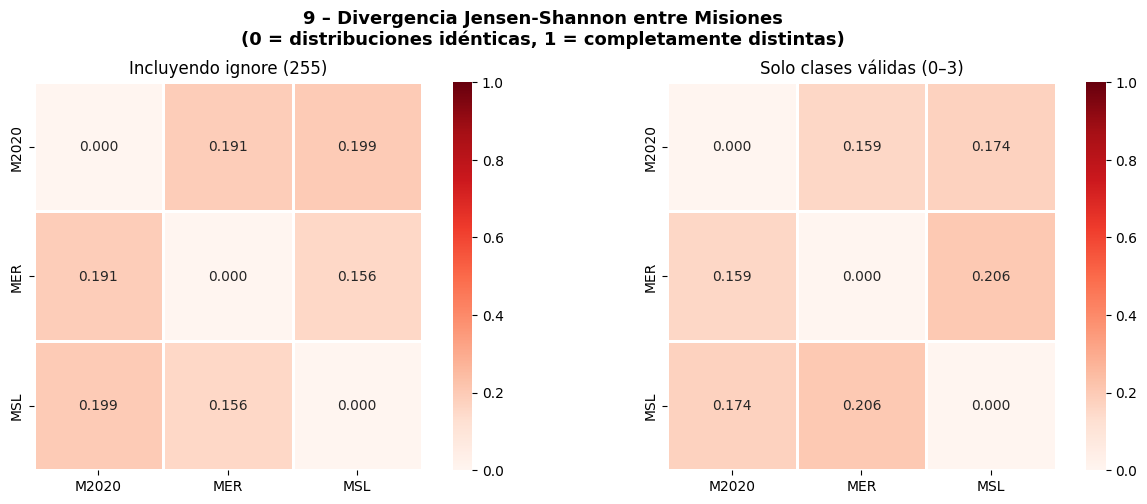

Divergencia Jensen-Shannon entre misiones (clases válidas 0–3):
  M2020 vs MER: JS = 0.1592  → ALTO domain shift
  M2020 vs MSL: JS = 0.1744  → ALTO domain shift
  MER vs MSL: JS = 0.2056  → ALTO domain shift


In [12]:
def get_dist_vector(dist: dict, classes: list) -> np.ndarray:
    """Convierte dict de distribución a vector de probabilidad normalizado."""
    vec = np.array([dist.get(c, 1e-9) for c in classes], dtype=float)
    return vec / vec.sum()


missions_js = sorted(dist_mission.keys())
n = len(missions_js)
js_full  = np.zeros((n, n))
js_valid = np.zeros((n, n))

for i, m1 in enumerate(missions_js):
    for j, m2 in enumerate(missions_js):
        v_full1  = get_dist_vector(dist_mission[m1], [0, 1, 2, 3, 255])
        v_full2  = get_dist_vector(dist_mission[m2], [0, 1, 2, 3, 255])
        js_full[i, j] = jensenshannon(v_full1, v_full2)

        v_valid1 = get_dist_vector(dist_mission[m1], [0, 1, 2, 3])
        v_valid2 = get_dist_vector(dist_mission[m2], [0, 1, 2, 3])
        js_valid[i, j] = jensenshannon(v_valid1, v_valid2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "9 – Divergencia Jensen-Shannon entre Misiones\n"
    "(0 = distribuciones idénticas, 1 = completamente distintas)",
    fontsize=13, fontweight="bold"
)

for ax, matrix, title in zip(
    axes,
    [js_full, js_valid],
    ["Incluyendo ignore (255)", "Solo clases válidas (0–3)"]
):
    sns.heatmap(
        matrix, annot=True, fmt=".3f",
        xticklabels=missions_js, yticklabels=missions_js,
        ax=ax, cmap="Reds", vmin=0, vmax=1,
        linewidths=1, square=True
    )
    ax.set_title(title)

plt.tight_layout()
plt.show()

print("Divergencia Jensen-Shannon entre misiones (clases válidas 0–3):")
for i, m1 in enumerate(missions_js):
    for j, m2 in enumerate(missions_js):
        if i < j:
            js = js_valid[i, j]
            level = "ALTO domain shift" if js > 0.15 else "moderado"
            print(f"  {m1} vs {m2}: JS = {js:.4f}  → {level}")

**Implicaciones – Divergencia Jensen-Shannon**

| | |
|---|---|
| **[D] Decisión** | JS > 0.15 entre misiones justifica formalmente **no mezclar misiones** en el entrenamiento sin domain adaptation explícita. |
| **[A] Arquitectura** | Un experimento cross-mission (train MSL → test MER/M2020) sería la prueba de generalización OOD natural. Se documenta como trabajo futuro. |
| **[R] Riesgo** | Mezclar MSL y MER en train sin control puede hacer que el modelo aprenda features de sensor en lugar de features de terreno. |

## 10. Decisión justificada: usar solo MSL <a id="decision"></a>

Con base en los análisis anteriores, se consolida la decisión de restringir el entrenamiento
a imágenes de la misión MSL (rover Curiosity, cámara NavCam).

In [13]:
# Tabla resumen de justificación
justificacion = pd.DataFrame([
    {
        "Criterio": "Tamaño del conjunto",
        "MSL": f"~{len(train_clean[train_clean.mission=='MSL']):,} imágenes (>70% del dataset)",
        "MER": f"~{len(train_clean[train_clean.mission=='MER']):,} imágenes",
        "M2020": f"~{len(train_clean[train_clean.mission=='M2020']):,} imágenes",
        "Decisión": "MSL es el conjunto más grande y representativo"
    },
    {
        "Criterio": "Domain shift (JS vs MSL)",
        "MSL": "0.000 (referencia)",
        "MER": f"{js_valid[missions_js.index('MSL'), missions_js.index('MER')]:.3f}",
        "M2020": f"{js_valid[missions_js.index('MSL'), missions_js.index('M2020')]:.3f}",
        "Decisión": "JS > 0.15 → mezcla sin domain adaptation es inapropiada"
    },
    {
        "Criterio": "Consistencia de sensor",
        "MSL": "NavCam (homogéneo)",
        "MER": "EFF (resolución y ángulo distintos)",
        "M2020": "NavCam (similar a MSL pero pocos datos)",
        "Decisión": "MSL tiene el sensor más consistente con más datos"
    },
    {
        "Criterio": "Gold set estándar",
        "MSL": "322 imágenes validadas por JPL (min3)",
        "MER": "Test set disponible pero distinto dominio",
        "M2020": "Sin gold set público",
        "Decisión": "Solo MSL tiene gold set comparable con la literatura"
    },
    {
        "Criterio": "Precedente en literatura",
        "MSL": "Li et al. (2024), Mohammad et al. (2024)",
        "MER": "No usado como conjunto principal",
        "M2020": "No usado como conjunto principal",
        "Decisión": "MSL permite comparabilidad directa con el estado del arte"
    },
])

print("Resumen de justificación para el uso exclusivo de MSL:")
print("=" * 80)
for _, row in justificacion.iterrows():
    print(f"\n► {row['Criterio']}")
    print(f"  MSL   : {row['MSL']}")
    print(f"  MER   : {row['MER']}")
    print(f"  M2020 : {row['M2020']}")
    print(f"  → {row['Decisión']}")

# Guardar manifest solo MSL
msl_train_clean = train_clean[train_clean["mission"] == "MSL"].reset_index(drop=True)
msl_train_clean.to_csv(PROCESSED_DIR / "manifest_msl_train.csv", index=False)
print(f"\nmanifest_msl_train.csv guardado: {len(msl_train_clean):,} imágenes MSL limpias")

Resumen de justificación para el uso exclusivo de MSL:

► Tamaño del conjunto
  MSL   : ~15,901 imágenes (>70% del dataset)
  MER   : ~6,593 imágenes
  M2020 : ~471 imágenes
  → MSL es el conjunto más grande y representativo

► Domain shift (JS vs MSL)
  MSL   : 0.000 (referencia)
  MER   : 0.206
  M2020 : 0.174
  → JS > 0.15 → mezcla sin domain adaptation es inapropiada

► Consistencia de sensor
  MSL   : NavCam (homogéneo)
  MER   : EFF (resolución y ángulo distintos)
  M2020 : NavCam (similar a MSL pero pocos datos)
  → MSL tiene el sensor más consistente con más datos

► Gold set estándar
  MSL   : 322 imágenes validadas por JPL (min3)
  MER   : Test set disponible pero distinto dominio
  M2020 : Sin gold set público
  → Solo MSL tiene gold set comparable con la literatura

► Precedente en literatura
  MSL   : Li et al. (2024), Mohammad et al. (2024)
  MER   : No usado como conjunto principal
  M2020 : No usado como conjunto principal
  → MSL permite comparabilidad directa con el e

**Implicaciones – Decisión MSL**

| | |
|---|---|
| **[D] Decisión** | Se usa **exclusivamente el subconjunto MSL** para entrenamiento y validación. El gold set MSL min3 es el test fijo. |
| **[A] Arquitectura** | No se requieren técnicas de domain adaptation en los modelos benchmark. Se documenta como extensión futura. |
| **[R] Riesgo** | Al restringir a MSL, el modelo no verá variabilidad de sensor de MER/M2020. La generalización a otras misiones queda fuera del alcance del entregable. |

## 11. Definición del gold set de test (MSL min3) <a id="goldset"></a>

El gold set corresponde a 322 imágenes MSL con máscaras validadas por científicos del JPL
con mínimo 3 etiquetadores en acuerdo al 100% (`masked-gold-min3-100agree`).  
Este conjunto se usa como **test fijo**, completamente separado del pool de entrenamiento.

Gold set MSL (min3): 322 imágenes

Verificación de data leakage:
  IDs en train MSL   : 15,901
  IDs en gold set    : 322
  Overlap (leakage)  : 0
  ✓ Sin overlap — gold set completamente separado del pool de entrenamiento

manifest_msl_gold_test.csv guardado.


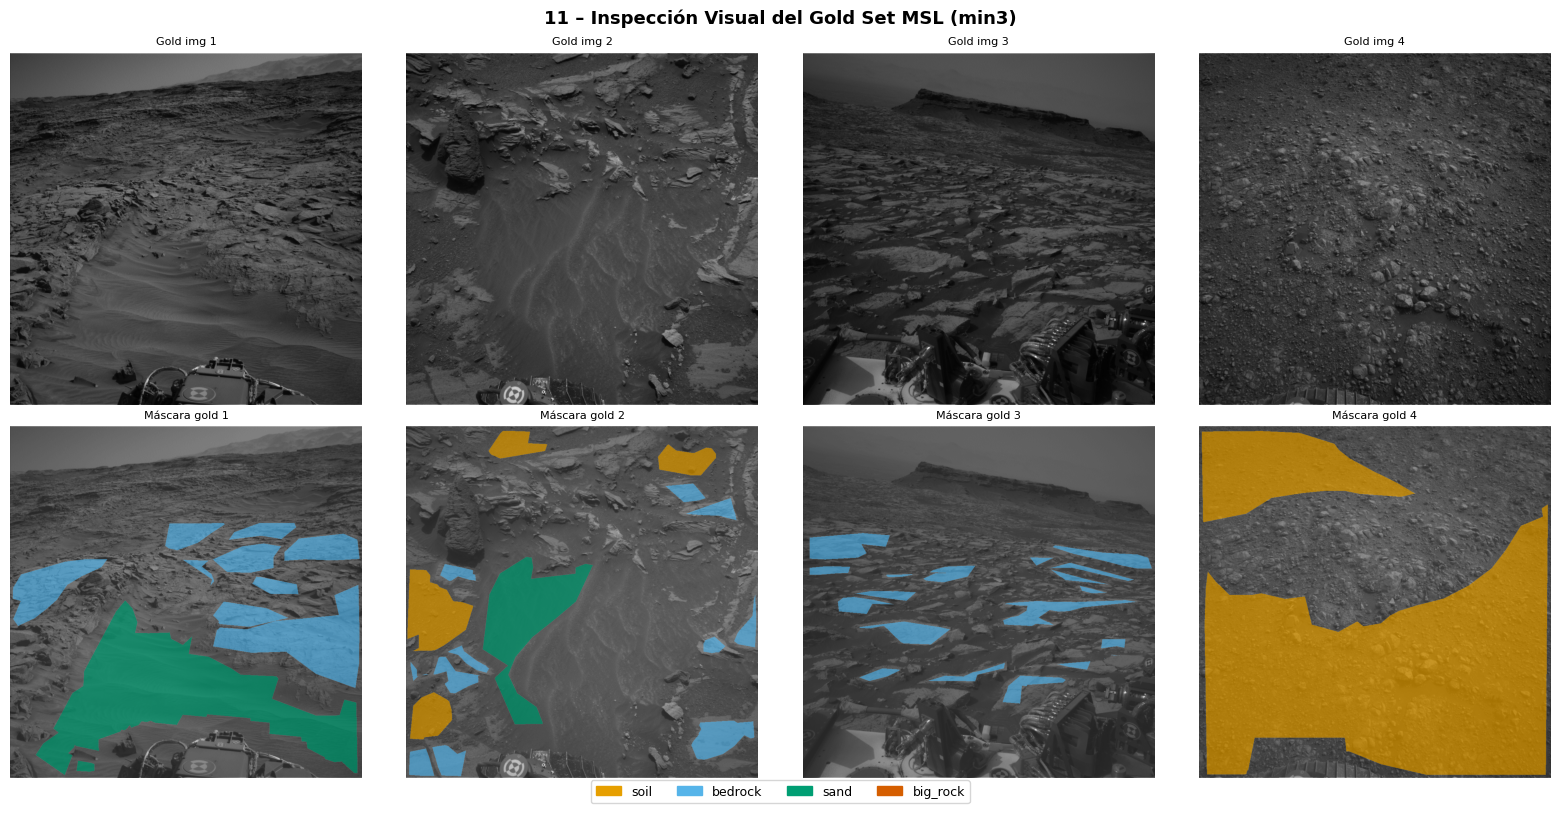

In [14]:
print(f"Gold set MSL (min3): {len(gold_set):,} imágenes")

# Verificar que no haya overlap entre el pool de train y el gold set
train_ids = set(msl_train_clean["id"].tolist())
gold_ids  = set(gold_set["id"].tolist())
overlap   = train_ids & gold_ids

print(f"\nVerificación de data leakage:")
print(f"  IDs en train MSL   : {len(train_ids):,}")
print(f"  IDs en gold set    : {len(gold_ids):,}")
print(f"  Overlap (leakage)  : {len(overlap)}")

assert len(overlap) == 0, (
    f"DATA LEAKAGE: {len(overlap)} imágenes aparecen en train Y en el gold set de test."
)
print("  ✓ Sin overlap — gold set completamente separado del pool de entrenamiento")

# Guardar gold set
gold_set.to_csv(PROCESSED_DIR / "manifest_msl_gold_test.csv", index=False)
print(f"\nmanifest_msl_gold_test.csv guardado.")

# Inspección visual del gold set
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("11 – Inspección Visual del Gold Set MSL (min3)",
             fontsize=13, fontweight="bold")

sample_gold = gold_set.sample(4, random_state=EDA_SEED)
for col_idx, (_, row) in enumerate(sample_gold.iterrows()):
    img  = np.array(Image.open(ROOT / row["image_path"]).convert("L"))
    mask = np.array(Image.open(ROOT / row["mask_path"]))

    axes[0][col_idx].imshow(img, cmap="gray")
    axes[0][col_idx].set_title(f"Gold img {col_idx+1}", fontsize=8)
    axes[0][col_idx].axis("off")

    overlay = np.zeros((*mask.shape, 4), dtype=np.uint8)
    for cls_id, (hex_color, _) in CLASS_COLORS.items():
        if cls_id == 255:
            continue
        rgb = tuple(int(hex_color[i:i+2], 16) for i in (1, 3, 5))
        overlay[mask == cls_id] = [*rgb, 180]
    overlay[mask == 255] = [150, 150, 150, 60]

    axes[1][col_idx].imshow(img, cmap="gray")
    axes[1][col_idx].imshow(overlay)
    axes[1][col_idx].set_title(f"Máscara gold {col_idx+1}", fontsize=8)
    axes[1][col_idx].axis("off")

patches = [
    mpatches.Patch(color=CLASS_COLORS[c][0], label=CLASS_COLORS[c][1])
    for c in [0, 1, 2, 3]
]
fig.legend(handles=patches, loc="lower center", ncol=4,
           fontsize=9, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

**Implicaciones – Gold set de test**

| | |
|---|---|
| **[D] Decisión** | El gold set MSL min3 es el **test set fijo** para todos los modelos. Nunca se usa en entrenamiento ni validación. Los resultados sobre este set son los reportados en el benchmark final. |
| **[A] Arquitectura** | Las métricas del gold set son comparables directamente con Li et al. (2024) y Mohammad et al. (2024). |
| **[R] Riesgo CRÍTICO** | Cualquier inspección de las máscaras gold durante el diseño del modelo constituye data leakage. Este notebook solo verifica el conteo y la separación — no analiza la distribución de clases del gold set. |

---

## Archivos generados por este notebook

| Archivo | Descripción | Usado en |
|---|---|---|
| `processed/manifest_clean.csv` | Todas las muestras válidas (train pool + gold set) | Referencia general |
| `processed/manifest_msl_train.csv` | Solo imágenes MSL limpias para entrenamiento | `02_preprocessing.ipynb` |
| `processed/manifest_msl_gold_test.csv` | Gold set MSL min3 (test fijo) | Notebooks de evaluación |
| `figures/eda_01/*.png` | Todas las figuras de este notebook | Jupyter Book |

> **Próximo paso**: `02_preprocessing.ipynb` — Resize a 256×256, generación del split train/val
> sobre el pool MSL, y cálculo de estadísticas de normalización solo sobre train.